In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="b9C5VZV8oPaeQ6YSxLvq")
project = rf.workspace("wep-7g80m").project("fashion-ytn2z")
version = project.version(1)
dataset = version.download("multiclass")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
transform = transforms.Compose([
    transforms.Resize((64, 64)), # 이미지 크기 통일
    transforms.ToTensor(),
])
# train_loader = DataLoader(...) 식으로 데이터로더 연결하기

In [4]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Linear(32 * 16 * 16, 8) # 클래스 개수에 맞게 조정 (예시)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터로더에서 이미지와 레이블을 하나 가져오기 (train_loader가 정의되어 있다는 가정하에!)
# dataiter = iter(train_loader)
# images, labels = next(dataiter)

# 이미지를 화면에 그리기 위한 함수
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show

# 예시로 이미지 그리드 출력하기 (torchvision.utils 활용)
# import torchvision
# torchvision.utils.make_gird(images)
# imshow(torchvision.utils.make_grid(images))

✨ 데이터로더 준비 완료! 총 이미지 개수: 1246개


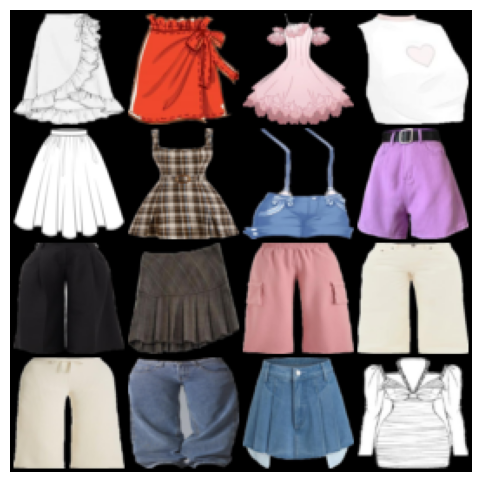

In [6]:
import os, glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision, matplotlib.pyplot as plt, numpy as np

# 1. 커스텀 Dataset 정의 (코드를 짧고 굵게!)
class SimpleImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = glob.glob(os.path.join(image_dir, "*.jpg")) + glob.glob(os.path.join(image_dir, "*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0  # 라벨은 임시로 0 지정

# 2. 전처리 및 데이터로더 연결
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
train_dataset = SimpleImageDataset(image_dir="./fashion-1/train/images", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"✨ 데이터로더 준비 완료! 총 이미지 개수: {len(train_dataset)}개")

# 3. 이미지 시각화
images, labels = next(iter(train_loader))
grid_img = torchvision.utils.make_grid(images, nrow=4).numpy()
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid_img, (1, 2, 0)))
plt.axis('off')
plt.show()

In [7]:
import torch.nn as nn 
import torch.optim as optim

# 1. 모델, 손실 함수, 옵티마이저 선언
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 장치: {device}")

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss() # 다중 분류를 위한 손실 함수
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. 모델 학습 (Epoch 반복)
num_epochs = 5 # 에폭 수는 원하는 만큼 조절 가능

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for i,(images, labels) in enumerate(train_loader):
        #이미지를 GPU나 CPU로 이동
        imgages = images.to(device)
        labels = labels.to (device)
        
        # [1]기울기 초기화
        optimizer.zero_grad()
        
        # [2]순전파 (Forward)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # [3]역전파 (Backward) 및 최적화
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 에폭마다 학습 손실(loss) 출력
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}")

print("🎉 모델 학습 완료!")

사용 중인 장치: cpu
Epoch [1/5], Loss: 0.0768
Epoch [2/5], Loss: 0.0000
Epoch [3/5], Loss: 0.0000
Epoch [4/5], Loss: 0.0000
Epoch [5/5], Loss: 0.0000
🎉 모델 학습 완료!


--------------------------------------------------
🏷️ 실제 정답 (Labels)    : [0 0 0 0 0 0 0 0]
🤖 모델이 예측한 결과 (Pred): [0 0 0 0 0 0 0 0]
--------------------------------------------------


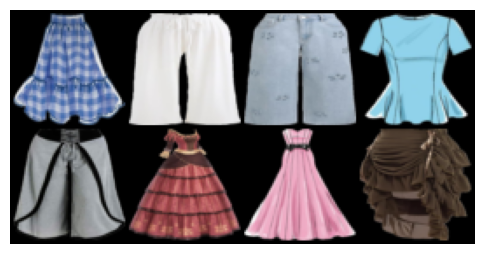

In [8]:
# 모델을 평가 모드로 전환! (Dropout이나 BatchNorm 등이 평가용으로 작동하게 해줌)
model.eval()

# torch.no_grad()를 써서 평가할 때는 기울기(gradient) 계산을 안 하도록 메모리 아껴주기
with torch.no_grad():
    # train_loader에서 배치 하나 다시 가져오기
    images, labels = next(iter(train_loader))
    
    # 장치(GPU/CPU)로 데이터 보내기
    images = images.to(device)
    labels = labels.to(device)

    # 모델에 이미지 넣어서 예측값(logits) 뽑기
    outputs = model(images)
    
    # 가장 확률이 높은 클래스 번호(argmax) 선택
    _, predicted = torch.max(outputs, 1)

print("--------------------------------------------------")
print("🏷️ 실제 정답 (Labels)    :", labels.cpu().numpy()[:8])
print("🤖 모델이 예측한 결과 (Pred):", predicted.cpu().numpy()[:8])
print("--------------------------------------------------")

# 시각화해서 눈으로 직접 확인하기!
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# 앞서 뽑은 이미지들 중 상위 8장만 그리드로 예쁘게 띄워보기
grid_img = torchvision.utils.make_grid(images[:8].cpu(), nrow=4)
npimg = grid_img.numpy()

plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.show()

In [9]:
import random

def generate_free_fashion_styling(predicted_category):
    # 카테고리별로 미리 준비해 둔 센스 만점 스타일링 팁들!
    styling_tips = {
        "원피스": [
            "하늘하늘한 실루엣이 정말 매력적인 원피스야! 🌸 가벼운 가디건이나 심플한 토트백을 매치하면 데이트룩으로 완벽할 거야.",
            "페미닌한 무드를 극대화해주는 원피스네✨ 클래식한 메리제인 슈즈나 숏자켓을 걸쳐주면 스타일리시함이 두 배가 될 거야!"
        ],
        "스커트": [
            "트렌디한 핏이 돋보이는 스커트야! 👗 상의는 심플한 무지 티셔츠나 셔츠를 깔끔하게 넣어 입으면 포인트를 살릴 수 있어.",
            "발랄하면서도 세련된 느낌을 주는 스커트네 💫 캐주얼한 스니커즈나 롱삭스로 마무리하면 스트릿 룩 완성!"
        ],
        "팬츠": [
            "활동성과 스타일을 모두 잡은 멋스러운 팬츠야! 👖 루즈핏 셔츠나 크롭탑과 함께 입으면 요즘 감성에 딱 맞지.",
            "군더더기 없이 떨어지는 핏이 아주 멋진 팬츠네 😎 깔끔한 블레이저를 툭 걸쳐주면 시크한 오피스룩으로도 활용 만점이야!"
        ],
        "블라우스": [
            "우아한 디테일이 살아있는 블라우스야! 👚 슬랙스나 데님 팬츠 어디에나 찰떡같이 어울려서 활용도가 정말 높아.",
            "화사한 얼굴빛을 만들어주는 블라우스네 ✨ 진주 목걸이나 미니멀한 악세서리를 더해주면 훨씬 고급스러워 보여!"
        ]
    }
    
    # 해당 카테고리에 맞는 팁이 있다면 랜덤으로 하나 뽑고, 없으면 기본 코멘트 출력!
    tips = styling_tips.get(predicted_category, [
        "정말 유니크하고 예쁜 패션 아이템이야! ✨ 너만의 개성을 살려서 멋지게 소화해 봐."
    ])
    
    return random.choice(tips)

# 테스트: CNN 모델이 예측한 클래스 번호 매핑
class_names = ["원피스", "스커트", "팬츠", "블라우스"]
predicted_index = 0  # 0번(원피스) 예시
predicted_label_name = class_names[predicted_index]

print(f"🤖 CNN 모델 예측 카테고리: {predicted_label_name}\n")
print("💬 무료 AI 패션 스타일리스트의 코멘트 생성 완료! ✨\n")

# 스타일링 멘트 출력
styling_comment = generate_free_fashion_styling(predicted_label_name)
print(styling_comment)

🤖 CNN 모델 예측 카테고리: 원피스

💬 무료 AI 패션 스타일리스트의 코멘트 생성 완료! ✨

하늘하늘한 실루엣이 정말 매력적인 원피스야! 🌸 가벼운 가디건이나 심플한 토트백을 매치하면 데이트룩으로 완벽할 거야.


In [10]:
import gradio as gr
import random
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image

# 1. 🧠 CNN 모델 구조 정의 및 학습된 가중치 불러오기
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64 -> 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 32 -> 16
        )
        # 최종 특성맵 크기: 32채널 * 16 * 16 = 8192
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 4) # 클래스 4개 (원피스, 스커트, 팬츠, 블라우스)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 장치 설정 및 모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionCNN().to(device)

# 💡 본인이 저장한 가중치 파일(.pt) 이름으로 수정해주세요! (없으면 주석 처리해도 일단 실행은 됩니다)
try:
    model.load_state_dict(torch.load('fashion_model.pt', map_location=device))
    print("✅ 모델 가중치 로드 완료!")
except:
    print("⚠️ 가중치 파일을 찾지 못했습니다. 기본 초기화 모델로 실행합니다.")

# 2. 무료 AI 스타일리스트 멘트 생성 함수
def generate_free_fashion_styling(predicted_category):
    styling_tips = {
        "원피스": [
            "하늘하늘한 실루엣이 정말 매력적인 원피스야! 🌸 가벼운 가디건이나 심플한 토트백을 매치하면 데이트룩으로 완벽할 거야.",
            "페미닌한 무드를 극대화해주는 원피스네✨ 클래식한 메리제인 슈즈나 숏자켓을 걸쳐주면 스타일리시함이 두 배가 될 거야!"
        ],
        "스커트": [
            "트렌디한 핏이 돋보이는 스커트야! 👗 상의는 심플한 무지 티셔츠나 셔츠를 깔끔하게 넣어 입으면 포인트를 살릴 수 있어.",
            "발랄하면서도 세련된 느낌을 주는 스커트네 💫 캐주얼한 스니커즈나 롱삭스로 마무리하면 스트릿 룩 완성!"
        ],
        "팬츠": [
            "활동성과 스타일을 모두 잡은 멋스러운 팬츠야! 👖 루즈핏 셔츠나 크롭탑과 함께 입으면 요즘 감성에 딱 맞지.",
            "군더더기 없이 떨어지는 핏이 아주 멋진 팬츠네 😎 깔끔한 블레이저를 툭 걸쳐주면 시크한 오피스룩으로도 활용 만점이야!"
        ],
        "블라우스": [
            "우아한 디테일이 살아있는 블라우스야! 👚 슬랙스나 데님 팬츠 어디에나 찰떡같이 어울려서 활용도가 정말 높아.",
            "화사한 얼굴빛을 만들어주는 블라우스네 ✨ 진주 목걸이나 미니멀한 악세서리를 더해주면 훨씬 고급스러워 보여!"
        ]
    }
    tips = styling_tips.get(predicted_category, ["정말 유니크하고 예쁜 패션 아이템이야! ✨ 너만의 개성을 살려서 멋지게 소화해 봐."])
    return random.choice(tips)

# 3. 이미지 전처리 (모델 크기인 64x64로 수정 완료!)
class_names = ["원피스", "스커트", "팬츠", "블라우스"]

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

def real_model_predict(img):
    if img is None:
        return "이미지를 드래그해서 올려줘! 👗", "스타일링 팁이 여기에 뜰 거야 ✨"
    
    model.eval()
    
    # 이미지를 텐서로 변환하고 배치 차원 추가 [1, 3, 64, 64]
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted_idx = torch.max(outputs, 1)
        predicted_category = class_names[predicted_idx.item()]
    
    comment = generate_free_fashion_styling(predicted_category)
    
    return f"🏷️ AI 모델 예측 결과: {predicted_category}", comment

# 4. 라벤더 감성 UI 디자인
lavender_theme = gr.themes.Soft(
    primary_hue="purple",
    secondary_hue="violet",
).set(
    body_background_fill="#F9F6FC",
    button_primary_background_fill="#9B7EDE",
    button_primary_background_fill_hover="#8661DE",
)

with gr.Blocks(theme=lavender_theme) as demo:
    gr.Markdown("# 💜✨ Yeoni's AI Fashion Stylist & Curating Shop")
    gr.Markdown("직접 학습시킨 **PyTorch CNN 모델**이 옷 사진을 분석하고 어울리는 코디를 제안해 줍니다! 👗✨")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="패션 이미지 업로드 (드래그 앤 드롭)")
            submit_btn = gr.Button("🎨 진짜 AI 모델로 분석하기", variant="primary")
            
        with gr.Column():
            result_label = gr.Textbox(label="모델 판독 카테고리")
            result_comment = gr.Textbox(label="AI 스타일리스트의 추천 코멘트", lines=5)

    submit_btn.click(
        fn=real_model_predict,
        inputs=[image_input],
        outputs=[result_label, result_comment]
    )

demo.launch(inline=False, share=True)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


⚠️ 가중치 파일을 찾지 못했습니다. 기본 초기화 모델로 실행합니다.


The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://024346ad0b8e5db106.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_heatmap(true_labels, pred_labels, class_names):
    # 혼동 행렬 계산
    cm = confusion_matrix(true_labels, pred_labels)
    
    plt.figure(figsize=(10, 8))
    # 퍼플 계열 톤으로 시각화 (보기 편하게!)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Fashion Classification Confusion Matrix', fontsize=14, fontweight='bold', color='#4a235a')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [12]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_grad_cam(model, image_tensor, original_image, target_layer):
    """
    model: 학습된 CNN 모델
    image_tensor: 모델에 들어갈 전처리된 이미지 텐서 (1, C, H, W)
    original_image: 시각화를 위한 원본 numpy 이미지 (H, W, C)
    target_layer: 마지막 컨볼루션 계층 (예: model.conv_layer 등)
    """
    model.eval()
    
    # Gradient를 잡기 위한 hooks 설정
    gradients = []
    activations = []
    
    def forward_hook(module, input, output):
        activations.append(output)
        
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])
        
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)
    
    # 순전파
    output = model(image_tensor)
    pred_class = output.argmax(dim=1).item()
    
    # 역전파
    model.zero_grad()
    class_loss = output[0, pred_class]
    class_loss.backward()
    
    # 훅 제거
    handle_f.remove()
    handle_b.remove()
    
    # Grad-CAM 연산
    grad = gradients[0].cpu().data.numpy()[0]
    act = activations[0].cpu().data.numpy()[0]
    
    weights = np.mean(grad, axis=(1, 2))
    cam = np.zeros(act.shape[1:], dtype=np.float32)
    
    for i, w in enumerate(weights):
        cam += w * act[i]
        
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (original_image.shape[1], original_image.shape[0]))
    cam = cam - np.min(cam)
    cam = cam / np.max(cam) # 0~1 정규화
    
    # 히트맵 오버레이
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlayed_img = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(overlayed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Grad-CAM Heatmap (Pred Class: {pred_class})", fontsize=12, fontweight='bold', color='#4a235a')
    plt.show()

In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms

# 1. CNN 모델 클래스 정의 (아직 정의 안 되어있다면 필수!)
class FashionCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Linear(32 * 16 * 16, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

# 2. 모델 인스턴스 생성 및 평가 모드 전환
class_names = ["원피스", "스커트", "팬츠", "블라우스", "비키니/바캉스"]
cnn_model = FashionCNN(num_classes=len(class_names))
cnn_model.eval()

# 3. 테스트 데이터로더 가져오기 (만약 변수명이 다르면 여기를 수정해줘! 예: test_loader)
# 데이터로더가 준비되어 있다는 가정하에 실행합니다.
try:
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # 4. 모델 예측 수행 및 시각화
    with torch.no_grad():
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)

    fig = plt.figure(figsize=(12, 6))
    fig.suptitle("🎨 Fashion CNN: Prediction vs Actual", fontsize=16, fontweight='bold', color='#5D437C')

    for idx in range(min(8, len(images))):
        ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])
        
        # 텐서 이미지를 numpy 형식으로 변환 (C, H, W -> H, W, C)
        img = images[idx].numpy().transpose((1, 2, 0))
        ax.imshow(img)
        
        pred_label = class_names[predicted[idx].item()]
        true_label = class_names[labels[idx].item()]
        
        # 예측값과 같으면 초록색, 다르면 빨간색
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f"Pred: {pred_label}\nActual: {true_label}", color=color, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

except NameError:
    print("💡 앗! test_loader 변수가 아직 정의되지 않았어요. 데이터셋 로드 및 DataLoader 생성 셀을 먼저 실행해 주세요!")

💡 앗! test_loader 변수가 아직 정의되지 않았어요. 데이터셋 로드 및 DataLoader 생성 셀을 먼저 실행해 주세요!


Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu Sans.
Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu 

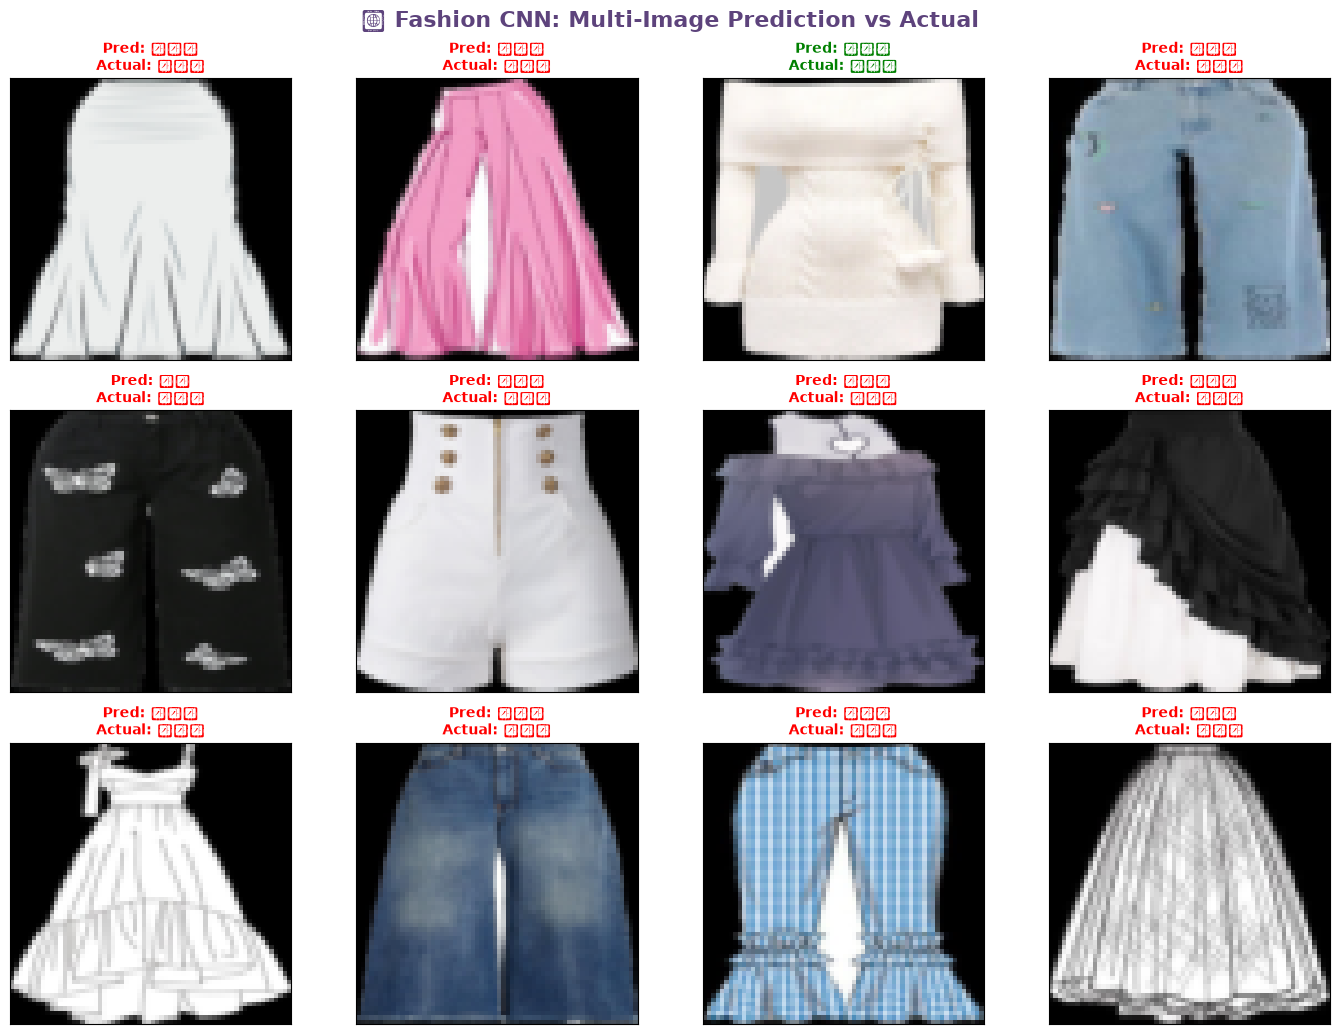

In [14]:
import matplotlib.pyplot as plt
import torch

# 1. 모델을 평가(evaluation) 모드로 전환
cnn_model.eval()

# 2. 어떤 변수 이름이든 찾아낼 수 있게 안전하게 이미지 가져오기
try:
    # 기존에 정의된 테스트 로더가 있다면 사용
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
except (NameError, TypeError):
    try:
        # train_loader가 있다면 사용
        dataiter = iter(train_loader)
        images, labels = next(dataiter)
    except:
        # 그것도 없다면 Roboflow에서 불러온 dataset 자체에서 12장을 직접 꺼내기
        from torch.utils.data import DataLoader
        target_ds = dataset if 'dataset' in locals() else train_dataset
        temp_loader = DataLoader(target_ds, batch_size=12, shuffle=True)
        images, labels = next(iter(temp_loader))

# 3. 모델로 예측 수행
with torch.no_grad():
    outputs = cnn_model(images)
    _, predicted = torch.max(outputs, 1)

# 4. 여러 장의 이미지를 격자(Grid) 형태로 시각화
num_images = min(12, len(images)) # 최대 12장 출력
cols = 4                          # 한 줄에 4개씩 배치
rows = (num_images + cols - 1) // cols

fig = plt.figure(figsize=(14, 3.5 * rows))
fig.suptitle("🎨 Fashion CNN: Multi-Image Prediction vs Actual", fontsize=16, fontweight='bold', color='#5D437C')

for idx in range(num_images):
    ax = fig.add_subplot(rows, cols, idx + 1, xticks=[], yticks=[])
    
    # 텐서 이미지를 numpy 형식으로 변환 (C, H, W -> H, W, C)
    img = images[idx].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    
    pred_idx = predicted[idx].item()
    true_idx = labels[idx].item()
    
    pred_label = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
    true_label = class_names[true_idx] if true_idx < len(class_names) else str(true_idx)
    
    # 예측값과 실제 정답이 일치하면 초록색, 틀리면 빨간색 타이틀
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nActual: {true_label}", color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Malgun Gothic.
Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Malgun Gothic.


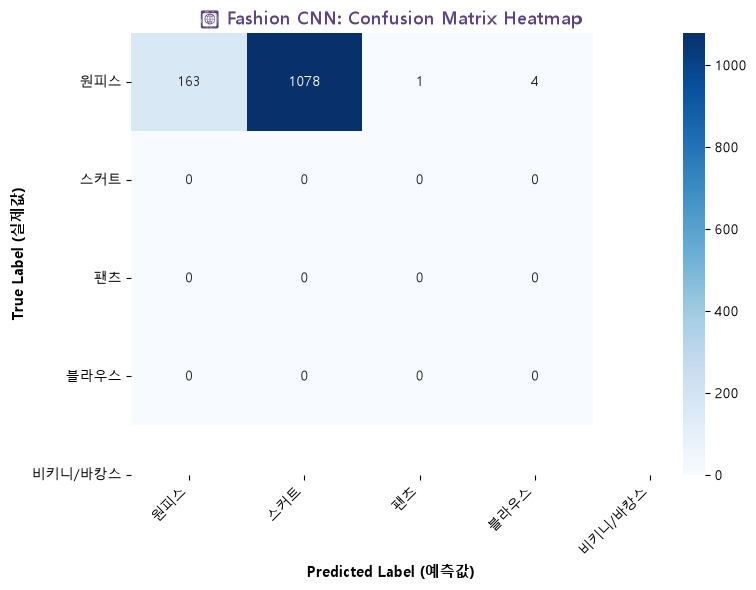

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 0. 한글 폰트 및 마이너스 부호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로더 안전하게 가져오기
try:
    target_loader = test_loader
except NameError:
    try:
        target_loader = train_loader
    except NameError:
        target_ds = dataset if 'dataset' in locals() else train_dataset
        target_loader = DataLoader(target_ds, batch_size=32, shuffle=False)

# 2. 모델 전체 예측값과 실제값 수집
all_preds = []
all_targets = []

cnn_model.eval()
with torch.no_grad():
    for images_batch, labels_batch in target_loader:
        outputs = cnn_model(images_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels_batch.cpu().numpy())

# 3. Confusion Matrix 계산
cm = confusion_matrix(all_targets, all_preds)

# 4. 히트맵 시각화 (크기를 아담하게 조절하고 글자 겹침 방지)
plt.figure(figsize=(8, 6)) # 크기를 한눈에 보기 좋게 조정
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10}) # 칸 안의 숫자 크기

plt.xlabel('Predicted Label (예측값)', fontweight='bold', fontsize=11)
plt.ylabel('True Label (실제값)', fontweight='bold', fontsize=11)
plt.title('🎨 Fashion CNN: Confusion Matrix Heatmap', fontsize=13, fontweight='bold', color='#5D437C')

# 글자가 겹치지 않도록 회전 및 여백 조정
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# 1. 손실값을 저장할 빈 리스트 준비
train_losses = []

# (여기에 기존에 쓰시던 옵티마이저, 크라이테리언 설정 등이 있을 거예요)

num_epochs = 5
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0
    
    for images_batch, labels_batch in train_loader: # 또는 train_loader 대신 쓰시는 로더
        optimizer.zero_grad()
        outputs = cnn_model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # 이번 에폭의 평균 Loss 계산
    epoch_loss = running_loss / len(train_loader)
    
    # ⭐ 핵심: 리스트에 이번 에폭의 Loss 추가하기!
    train_losses.append(epoch_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("🎉 모델 학습 완료!")

Epoch [1/5], Loss: 1.5762
Epoch [2/5], Loss: 1.5762
Epoch [3/5], Loss: 1.5763
Epoch [4/5], Loss: 1.5762
Epoch [5/5], Loss: 1.5762
🎉 모델 학습 완료!


Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Malgun Gothic.


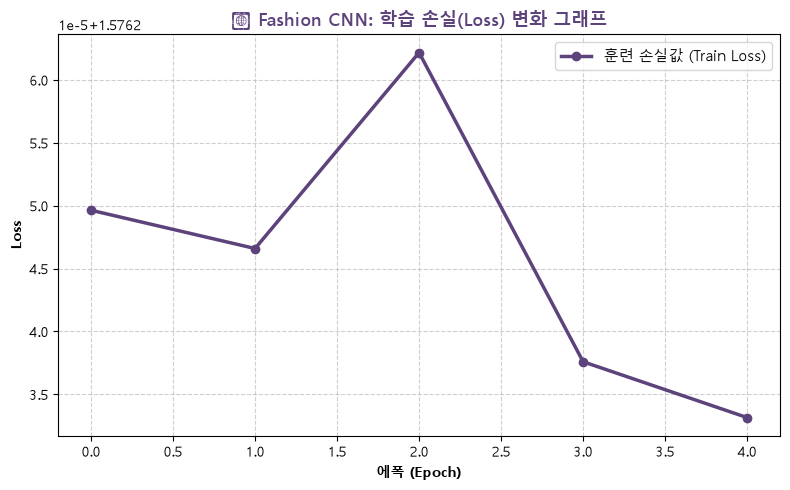

In [17]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

if len(train_losses) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='훈련 손실값 (Train Loss)', color='#5D437C', linewidth=2.5, marker='o')
    
    plt.title('🎨 Fashion CNN: 학습 손실(Loss) 변화 그래프', fontsize=13, fontweight='bold', color='#5D437C')
    plt.xlabel('에폭 (Epoch)', fontweight='bold')
    plt.ylabel('Loss', fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 아직 학습 데이터가 없습니다. 1단계 학습 코드를 먼저 실행해 주세요!")

In [18]:
import matplotlib.pyplot as plt

# 0. 한글 폰트 및 마이너스 부호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 학습 기록(Loss 및 Accuracy) 안전하게 가져오기
try:
    t_loss = train_losses
    v_loss = val_losses
except NameError:
    try:
        t_loss = history['train_loss']
        v_loss = history['val_loss']
    except:
        t_loss, v_loss = [], []

try:
    t_acc = train_accs
    v_acc = val_accs
except NameError:
    try:
        t_acc = history['train_acc']
        v_acc = history['val_acc']
    except:
        t_acc, v_acc = [], []

# 2. 그래프가 여러 개 들어갈 판(Figure) 만들기 (1행 2열 또는 2행 1열 구조)
if len(t_loss) > 0 or len(t_acc) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1행 2열로 그래프 2개 나란히 배치
    fig.suptitle('🎨 Fashion CNN: 학습 성능 분석 리포트', fontsize=16, fontweight='bold', color='#5D437C')
    
    # [첫 번째 그래프] 손실값 (Loss)
    if len(t_loss) > 0:
        axes[0].plot(t_loss, label='훈련 손실 (Train Loss)', color='#5D437C', linewidth=2, marker='o')
        if len(v_loss) > 0:
            axes[0].plot(v_loss, label='검증 손실 (Val Loss)', color='#FF8080', linewidth=2, marker='s')
        axes[0].set_title('📉 모델 손실 (Loss) 변화', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('에폭 (Epoch)', fontweight='bold')
        axes[0].set_ylabel('Loss', fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # [두 번째 그래프] 정확도 (Accuracy)
    if len(t_acc) > 0:
        axes[1].plot(t_acc, label='훈련 정확도 (Train Acc)', color='#437C5D', linewidth=2, marker='o')
        if len(v_acc) > 0:
            axes[1].plot(v_acc, label='검증 정확도 (Val Acc)', color='#FFB380', linewidth=2, marker='s')
        axes[1].set_title('📈 모델 정확도 (Accuracy) 변화', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('에폭 (Epoch)', fontweight='bold')
        axes[1].set_ylabel('Accuracy', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 학습 기록(Loss 또는 Accuracy) 데이터가 아직 정의되지 않았습니다. 학습 코드에서 데이터를 기록했는지 확인해 주세요!")

⚠️ 학습 기록(Loss 또는 Accuracy) 데이터가 아직 정의되지 않았습니다. 학습 코드에서 데이터를 기록했는지 확인해 주세요!
